Este notebook realiza una exploración inicial de datos de precios de acciones de **30 empresas** (2010–2026).

Se descargaron datos históricos y se validó la integridad de los datos verificando:

- ausencia de valores nulos  
- tipos de datos correctos  
- fechas ordenadas  
- detección de huecos temporales  
- ausencia de valores negativos  

Finalmente, se analizó el rango temporal de existencia de cada activo para establecer un **universo dinámico de acciones**.


In [11]:
# imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

sys.path.append(os.path.abspath(".."))
from src.data.download_data import DownloadData

import pandas_market_calendars as mcal





In [54]:
# descargar datos y preparar
tickers = [
    # Tecnología
    "AAPL", "MSFT", "NVDA", "GOOG", "META", "AVGO",

    # Consumo discrecional
    "AMZN", "HD", "MCD", "NKE",

    # Salud
    "JNJ", "UNH", "PFE", "ABBV",

    # Industriales
    "CAT", "BA", "UPS", "MMM",

    # Energía
    "XOM", "CVX", "SLB",

    # Finanzas
    "JPM", "BAC", "GS", "MS",

    # Utilities / Materiales
    "NEE", "LIN", "DOW",

    # Telecom / Comunicaciones
    "VZ", "CMCSA"
]

dd = DownloadData(tickers)
dd.download_tick_data()

dfs = {tick:pd.read_csv(os.path.join("/Users/jaime/Documents/UPM/TFG/data/raw/",csv), header=[0,1], index_col=0) for tick,csv in zip(sorted(tickers),sorted(os.listdir("/Users/jaime/Documents/UPM/TFG/data/raw/")))}



SyntaxError: invalid syntax (1964734718.py, line 31)

In [50]:
# mirar datos

df = pd.read_csv("/Users/jaime/Documents/UPM/TFG/data/raw/AAPL.csv", header=[0,1], index_col=0)

df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.412384,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.423471,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.321295,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.309610,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.351558,7.570714,7.571429,7.466429,7.510714,447610800


In [51]:
# hace falta eliminar la fila de Ticker y limpiar el df para que sea mas visual
df = df.droplevel(1,axis=1)
df.columns.name = None
df.head()


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,6.412384,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.423471,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.321295,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.309610,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.351558,7.570714,7.571429,7.466429,7.510714,447610800


In [52]:
# ver valores nulos
df.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [53]:
# ver si hay huecos vacios en algun dato en alguno de los 30 activos
for ticker,df in dfs.items():
    print(f"{ticker}: {df.isna().sum().sum() == 0}")

AttributeError: 'tuple' object has no attribute 'isna'

In [44]:
# no faltan datos
# ver que el tipo de datos para todo los df es corecto

expected_types = {
    'Open': 'float64',
    'High': 'float64',
    'Low': 'float64',
    'Close': 'float64',
    'Adj Close': 'float64',
    'Volume': 'int64'
}

for ticker,df in dfs.items():
    df = df.droplevel(1,axis=1)
    df.columns.name = None
    for col, expected in expected_types.items():
        if df[col].dtype != expected:
                print(f"{ticker}: {col} dtype incorrecto: {df[col].dtype} (esperado {expected})")




In [22]:
# el tipo de datos es corecto
# ver si estan ordenados en orden lineal temporal


for ticker,df in dfs.items():
    is_sorted = df.index.is_monotonic_increasing
    print(f"{ticker}: Fechas ordenadas: {is_sorted}")


BA.csvFechas ordenadas: True
BAC.csvFechas ordenadas: True
ABBV.csvFechas ordenadas: True
CAT.csvFechas ordenadas: True
MCD.csvFechas ordenadas: True
AMZN.csvFechas ordenadas: True
MMM.csvFechas ordenadas: True
NEE.csvFechas ordenadas: True
UPS.csvFechas ordenadas: True
MSFT.csvFechas ordenadas: True
NVDA.csvFechas ordenadas: True
HD.csvFechas ordenadas: True
XOM.csvFechas ordenadas: True
CVX.csvFechas ordenadas: True
CMCSA.csvFechas ordenadas: True
NKE.csvFechas ordenadas: True
LIN.csvFechas ordenadas: True
GS.csvFechas ordenadas: True
JPM.csvFechas ordenadas: True
META.csvFechas ordenadas: True
GOOG.csvFechas ordenadas: True
PFE.csvFechas ordenadas: True
AVGO.csvFechas ordenadas: True
VZ.csvFechas ordenadas: True
MS.csvFechas ordenadas: True
UNH.csvFechas ordenadas: True
SLB.csvFechas ordenadas: True
AAPL.csvFechas ordenadas: True
DOW.csvFechas ordenadas: True
JNJ.csvFechas ordenadas: True


In [23]:
# estan ordenadas
# hay huecos temporales?

start = "2010-01-01"
end = "2026-02-01"


nyse = mcal.get_calendar('NYSE')
schedule = nyse.schedule(start_date=start, end_date=end)
expected_days = mcal.date_range(schedule, frequency='1D')
expected_days = expected_days.normalize().tz_localize(None)

for ticker,df in dfs.items():
    df.index = pd.to_datetime(df.index, utc=True)
    df_days = df.index.normalize().tz_localize(None)
    missing_days = expected_days.difference(df_days)
    extra_days = df_days.difference(expected_days)
    duplicates = df.index[df.index.duplicated()]
    print(f"{ticker}: Missing days: ", missing_days)
    print(f"{ticker}: Extra days: ", extra_days)
    print(f"{ticker}: Duplicates: ",duplicates)
    

BA.csv: Missing days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
BA.csv: Extra days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
BA.csv: Duplicates:  DatetimeIndex([], dtype='datetime64[ns, UTC]', name='Date', freq=None)
BAC.csv: Missing days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
BAC.csv: Extra days:  DatetimeIndex([], dtype='datetime64[ns]', freq=None)
BAC.csv: Duplicates:  DatetimeIndex([], dtype='datetime64[ns, UTC]', name='Date', freq=None)
ABBV.csv: Missing days:  DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-11', '2010-01-12', '2010-01-13',
               '2010-01-14', '2010-01-15',
               ...
               '2012-12-17', '2012-12-18', '2012-12-19', '2012-12-20',
               '2012-12-21', '2012-12-24', '2012-12-26', '2012-12-27',
               '2012-12-28', '2012-12-31'],
              dtype='datetime64[ns]', length=754, freq=None)
ABBV.csv: Extra days:  DatetimeIndex(

In [25]:
# no hay huecos temporales, para las acciones que se incorporan tarde usamos universo de acciones dinamco

# ver si hay algun valor negativo en los df


for ticker,df in dfs.items():
    print(f"{ticker}: ", (df < 0).any())


BA.csv:  Price      Ticker
Adj Close  BA        False
Close      BA        False
High       BA        False
Low        BA        False
Open       BA        False
Volume     BA        False
dtype: bool
BAC.csv:  Price      Ticker
Adj Close  BAC       False
Close      BAC       False
High       BAC       False
Low        BAC       False
Open       BAC       False
Volume     BAC       False
dtype: bool
ABBV.csv:  Price      Ticker
Adj Close  ABBV      False
Close      ABBV      False
High       ABBV      False
Low        ABBV      False
Open       ABBV      False
Volume     ABBV      False
dtype: bool
CAT.csv:  Price      Ticker
Adj Close  CAT       False
Close      CAT       False
High       CAT       False
Low        CAT       False
Open       CAT       False
Volume     CAT       False
dtype: bool
MCD.csv:  Price      Ticker
Adj Close  MCD       False
Close      MCD       False
High       MCD       False
Low        MCD       False
Open       MCD       False
Volume     MCD       False
dt

In [97]:
# no hay valores negativos
# vamos a ver estadisticas basicas de algunos activos

# calculamos para cada activo su rango de existencia temporal
for ticker,df in dfs.items():
    df.index = df.index.normalize().tz_localize(None)
    start = df.index[0]
    end = df.index[len(df.index)-1]
    print(f"{ticker}: {start} - {end}")

AAPL: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
ABBV: 2013-01-02 00:00:00 - 2026-01-30 00:00:00
AMZN: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
AVGO: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
BA: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
BAC: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
CAT: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
CMCSA: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
CVX: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
DOW: 2019-03-20 00:00:00 - 2026-01-30 00:00:00
GOOG: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
GS: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
HD: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
JNJ: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
JPM: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
LIN: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
MCD: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
META: 2012-05-18 00:00:00 - 2026-01-30 00:00:00
MMM: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
MS: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
MSFT: 2010-01-04 00:00:00 - 2026-01-30 00:00:00
NEE: 201

In [101]:
# vemos que activos se incorporan tarde y en que fecha

start_actual = pd.Timestamp('2010-01-04 00:00:00')

for ticker,df in dfs.items():
    df.index = df.index.normalize().tz_localize(None)
    start = df.index[0]
    if start != start_actual:
        print(f"{ticker}: {start}")


ABBV: 2013-01-02 00:00:00
DOW: 2019-03-20 00:00:00
META: 2012-05-18 00:00:00


In [103]:
# calculamos medias,mediana, minimo y maximo

for ticker, df in dfs.items():
    print("\n" + "="*60)
    print(f"Estadísticas para {ticker}")
    print("="*60)
    print(df.describe().round(3))   # redondea para que sea más legible




Estadísticas para AAPL
Price  Adj Close     Close      High       Low      Open        Volume
Ticker      AAPL      AAPL      AAPL      AAPL      AAPL          AAPL
count   4044.000  4044.000  4044.000  4044.000  4044.000  4.044000e+03
mean      78.328    80.734    81.534    79.863    80.672  2.181747e+08
std       75.835    75.560    76.296    74.750    75.487  2.152739e+08
min        5.754     6.859     7.000     6.795     6.870  1.791060e+07
25%       18.275    21.591    21.720    21.370    21.533  7.703408e+07
50%       39.250    41.701    42.240    41.228    41.684  1.302068e+08
75%      143.472   146.513   147.978   145.020   146.245  2.889565e+08
max      285.922   286.190   288.620   283.300   286.200  1.880998e+09

Estadísticas para ABBV
Price  Adj Close     Close      High       Low      Open        Volume
Ticker      ABBV      ABBV      ABBV      ABBV      ABBV          ABBV
count   3290.000  3290.000  3290.000  3290.000  3290.000  3.290000e+03
mean      87.059   104.740   

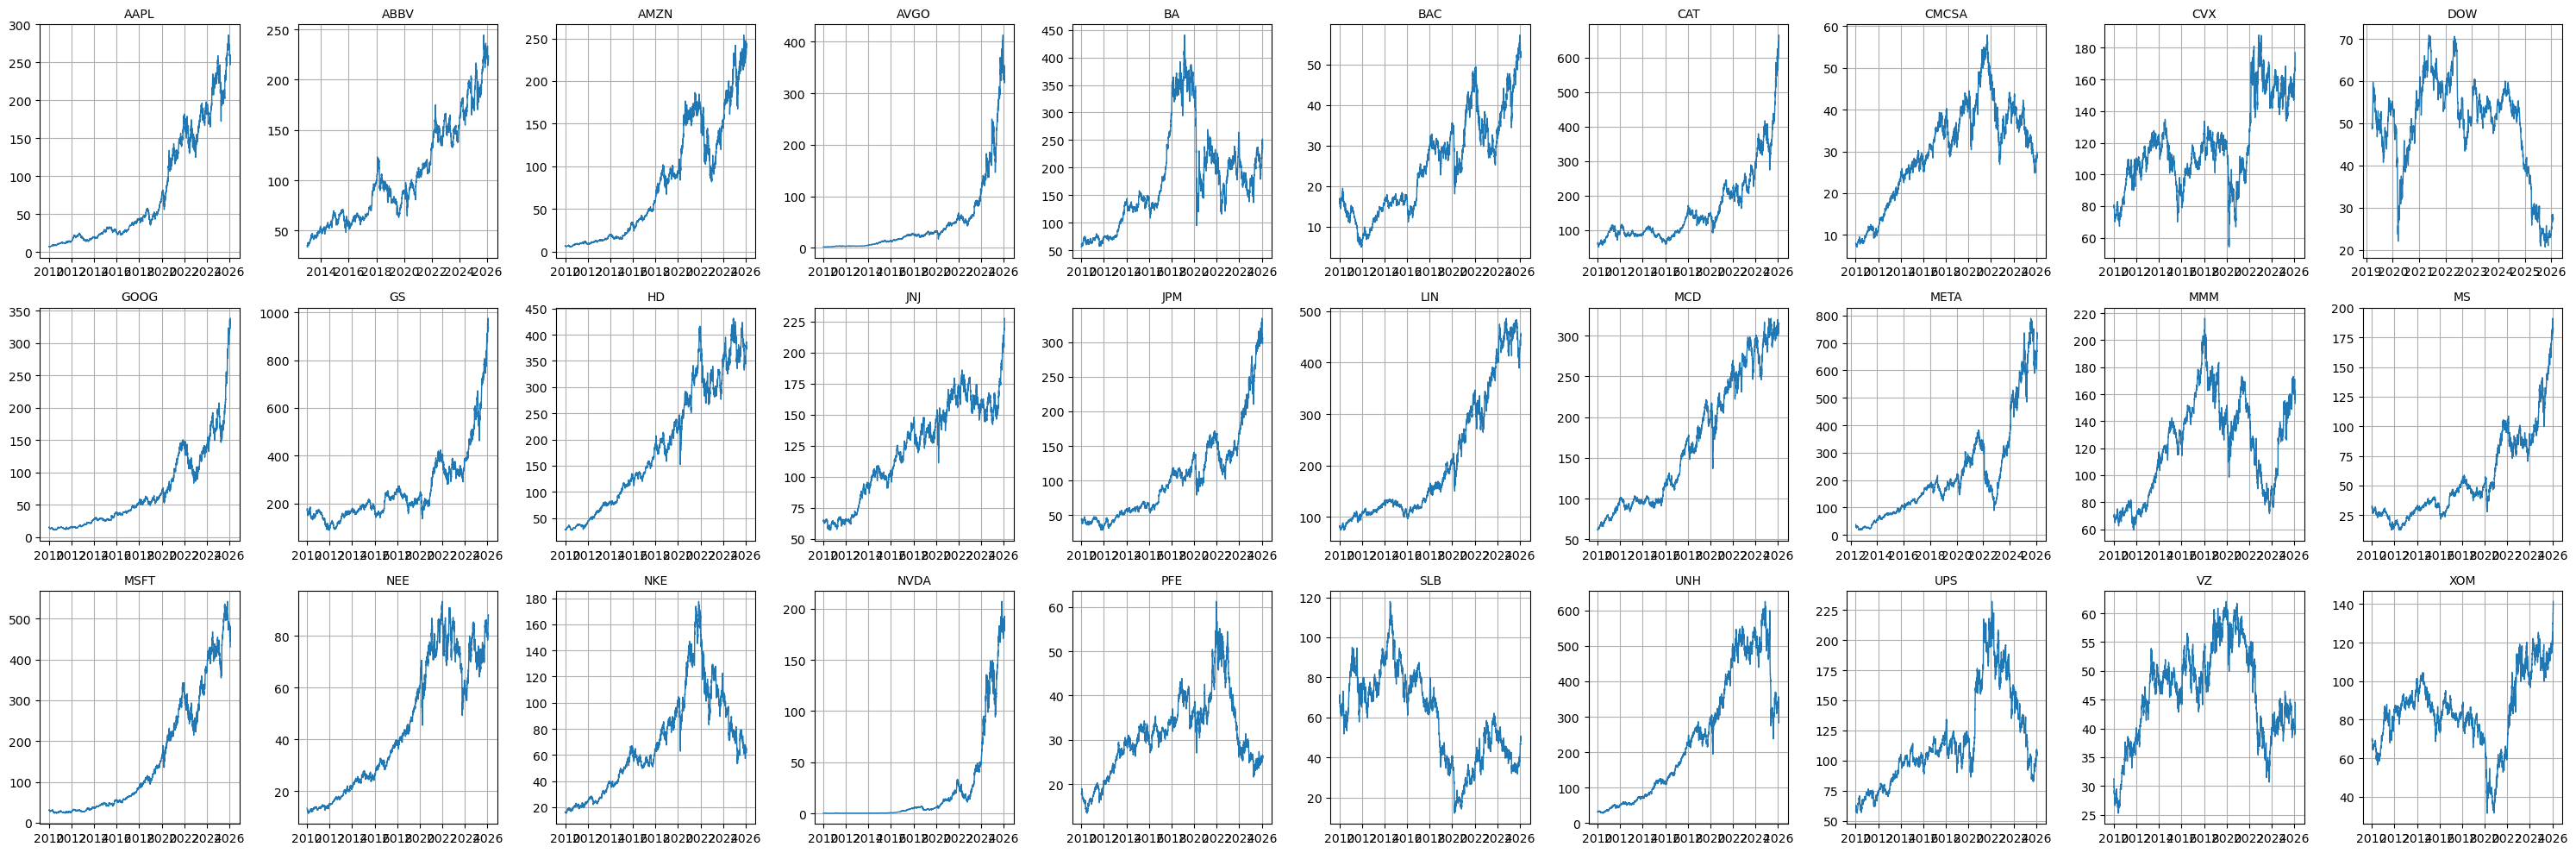

In [104]:
# graficas de precios de cierre para activos

tickers = list(dfs.keys())
n = len(tickers)

rows = 3
cols = 10

fig, axes = plt.subplots(rows, cols, figsize=(30, 10), sharex=False, sharey=False)
axes = axes.flatten()  # para indexar fácilmente

for i, ticker in enumerate(tickers):
    ax = axes[i]
    df = dfs[ticker]
    ax.plot(df['Close'], linewidth=1)
    ax.set_title(ticker, fontsize=10)
    ax.grid(True)

# Si hay más subplots que tickers, los vaciamos
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


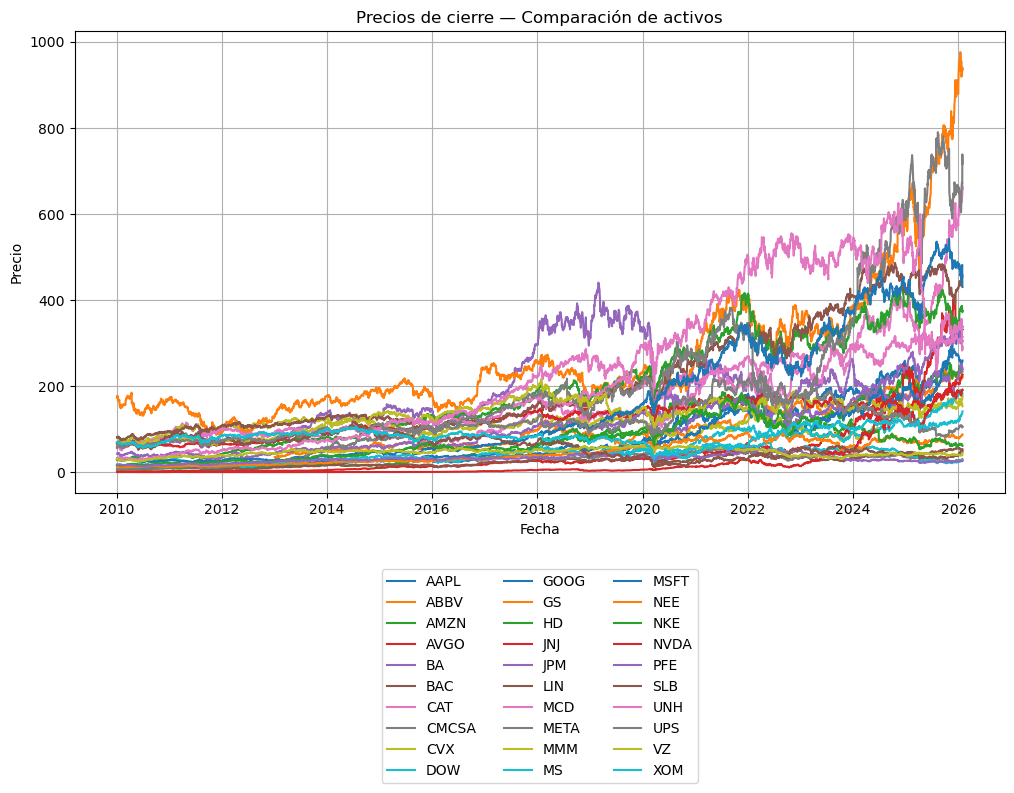

In [105]:

plt.figure(figsize=(12,6))

for ticker, df in dfs.items():
    plt.plot(df['Close'], label=ticker)

plt.title('Precios de cierre — Comparación de activos')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.show()



## Resumen completo de descubrimientos sobre los datos

### Integridad de datos

- Sin datos nulos: los 30 activos no presentan valores faltantes.  
- Tipos de datos correctos: *Open, High, Low, Close, Adj Close* (`float64`) y *Volume* (`int64`).  
- Fechas ordenadas cronológicamente: todos los activos están ordenados temporalmente.  
- Sin huecos temporales: coinciden con el calendario de operación de la NYSE.  
- Sin duplicados ni valores negativos.

### Activos que se incorporan tarde

- **META**: desde *2012-05-18* (IPO).  
- **ABBV**: desde *2013-01-02*.  
- **DOW**: desde *2019-03-20*.

### Análisis de estadísticas descriptivas

Las estadísticas de los 30 activos muestran una **fuerte heterogeneidad**:

- **Alto crecimiento**: NVDA, MSFT, GOOG, META y AAPL presentan precios medios elevados y máximos muy altos, reflejando tendencias claramente alcistas desde 2010.
- **Crecimiento moderado**: AMZN, AVGO, JPM, UNH o LIN alcanzan máximos entre 200 y 500, con volatilidad intermedia.
- **Activos estables**: Energía, utilities y materiales (XOM, CVX, NEE, VZ, DOW) muestran precios más contenidos y menor volatilidad.
- **Volúmenes**: Amplia variabilidad entre activos, sin anomalías relevantes.

### Análisis de gráficos

#### Comparación de precios de cierre (2010–2026)
El gráfico conjunto evidencia:

- **Tecnología en fuerte ascenso**, especialmente NVDA, MSFT y GOOG, con aceleración desde 2016–2020.
- **Impacto de la crisis de 2020**, con caídas generalizadas y recuperaciones más rápidas en tecnología que en energía o finanzas.
- **Divergencia sectorial**: sectores defensivos con trayectorias planas frente a sectores de crecimiento con tendencias marcadamente ascendentes.

#### Gráficos individuales
El análisis por activo muestra:

- **Tendencia alcista generalizada** en la mayoría de activos desde 2010.
- **Volatilidad diferenciada** según sector: defensivos más estables, cíclicos más irregulares.
- **Recuperación post‑COVID** en todos los activos, aunque con ritmos distintos.
- **Patrones sectoriales claros**, como la recuperación tardía de energía frente al crecimiento continuo de tecnología.


### Conclusiones principales

1. **Dataset de alta calidad**: Íntegridad perfecta, sin necesidad de limpieza adicional.
2. **Comportamiento heterogéneo**: Los 30 activos revelan patrones muy diversos según sector, permitiendo análisis de regímenes y rotación sectorial.
3. **Eventos macroeconómicos visibles**: Crisis de 2020, recuperación posterior, transformación digital (tecnología) e inflación (energía) están claramente documentados en los precios.
4. **Universo dinámico necesario**: La incorporación tardía de META, ABBV y DOW requiere un universo de acciones dinámico para análisis de backtesting.

---